In [1]:
# --- Imports ---
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
from src.splits import stratified_split
from src.experiments import (
    run_computational_benchmark,
    run_hyperparameter_sweep,
    evaluate_baselines,
    evaluate_test_set,
)

In [2]:
# --- Load Data ---
df = pd.read_csv("../data/titanic_cleaned.csv")

X = df.drop(columns=["survived"]).values
y = df["survived"].values

print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Positive rate: {y.mean():.4f}")

Dataset shape: X=(1309, 10), y=(1309,)
Positive rate: 0.3820


In [3]:
# --- Stratified Split ---
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X,
    y,
    train_frac=0.6,
    val_frac=0.2,
    test_frac=0.2,
    seed=42
)

print(f"Train positive rate: {y_train.mean():.4f} (n={len(y_train)})")
print(f"Val positive rate:   {y_val.mean():.4f} (n={len(y_val)})")
print(f"Test positive rate:  {y_test.mean():.4f} (n={len(y_test)})")

Train positive rate: 0.3812 (n=787)
Val positive rate:   0.3831 (n=261)
Test positive rate:  0.3831 (n=261)


Running benchmark (N = 100 → 10000)...


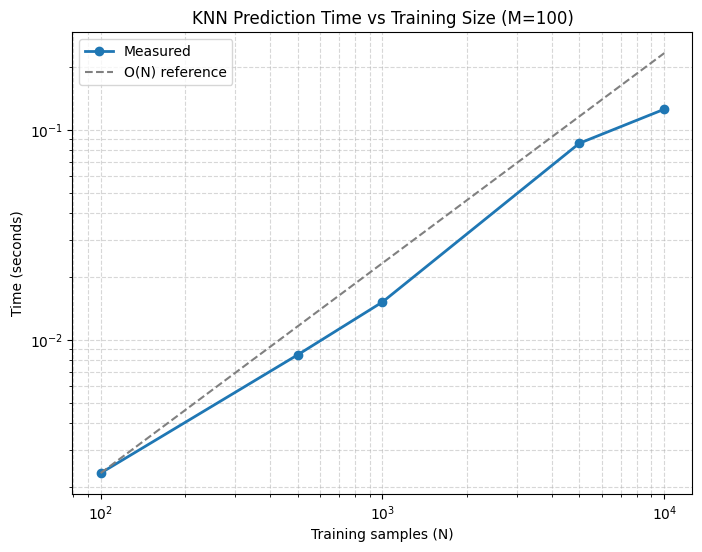

N=  100 -> 0.00232s
N=  500 -> 0.00848s
N= 1000 -> 0.01514s
N= 5000 -> 0.08638s
N=10000 -> 0.12542s


In [4]:
# --- Computational Benchmark ---
print("Running benchmark (N = 100 → 10000)...")

N_values, times = run_computational_benchmark(
    X_train,
    y_train,
    X_test,
    k=5,
    m_test=100
)

for n, t in zip(N_values, times):
    print(f"N={n:5d} -> {t:.5f}s")

Searching best k value...


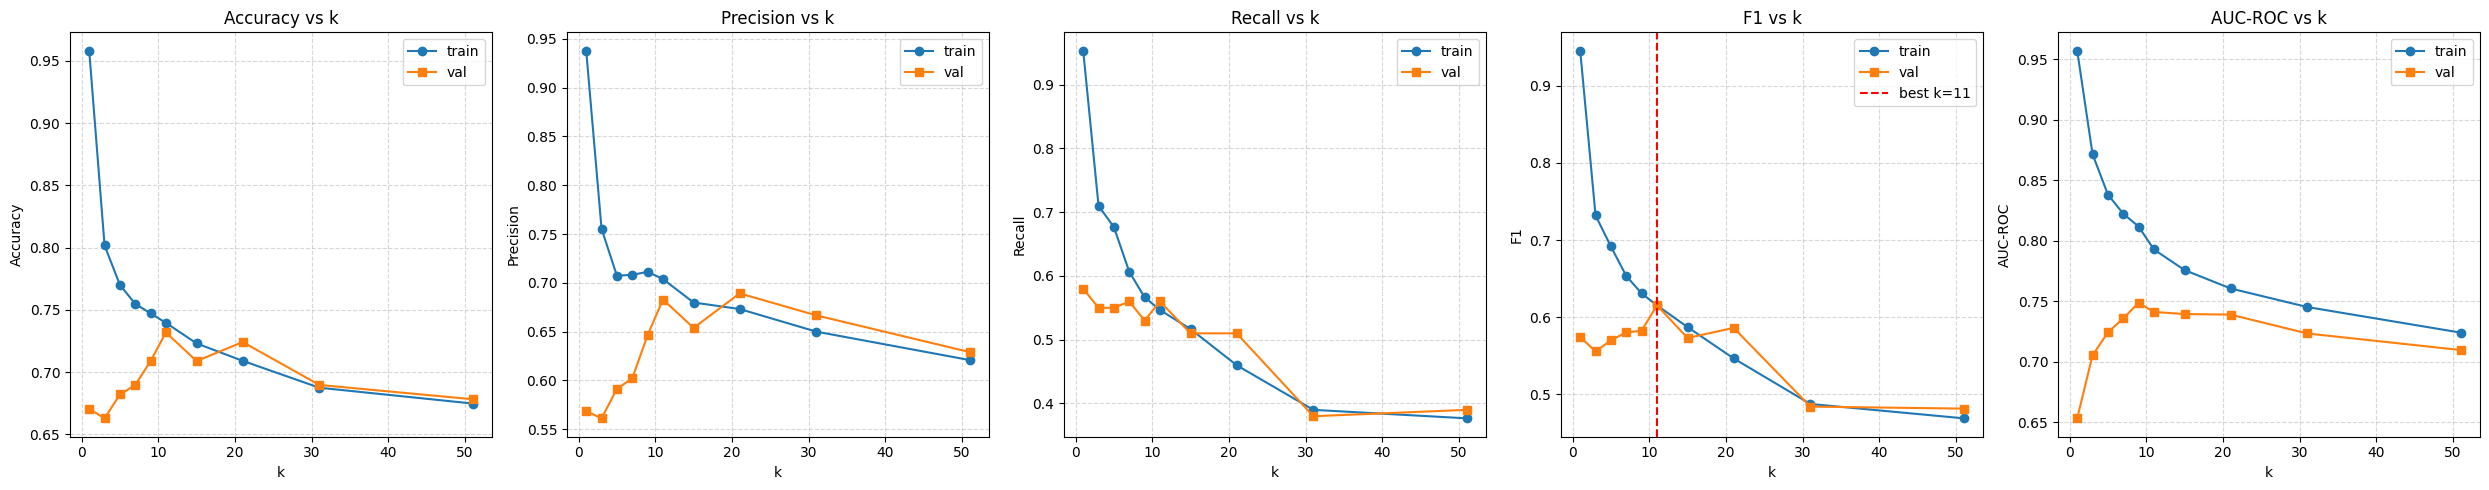


Best k (by validation F1): 11


In [5]:
# --- Hyperparameter Search ---
print("Searching best k value...")

best_k = run_hyperparameter_sweep(
    X_train,
    y_train,
    X_val,
    y_val
)

print(f"\nBest k (by validation F1): {best_k}")

In [6]:
# --- Baseline Comparison ---
print(f"Baseline comparison (k={best_k})...")

baseline_results = evaluate_baselines(
    X_train,
    y_train,
    X_val,
    y_val,
    best_k
)

display(baseline_results)

Baseline comparison (k=11)...


,Accuracy,Precision,Recall,F1 Score,AUC-ROC
Model,,,,,
Custom KNN (k=11),0.731801,0.682927,0.56,0.615385,0.741273
Sklearn KNN (k=11),0.731801,0.682927,0.56,0.615385,0.740186
Majority baseline,0.616858,0.000000,0.00,0.000000,0.500000


In [7]:
# --- Final Evaluation ---
print(f"Final test evaluation (k={best_k})...")

test_results = evaluate_test_set(
    X_train,
    y_train,
    X_test,
    y_test,
    best_k
)

display(test_results)

Final test evaluation (k=11)...


,Test Score
Metric,
Accuracy,0.724138
Precision,0.648936
Recall,0.610000
F1 Score,0.628866
AUC-ROC,0.754379
